In [2]:
import json
from pathlib import Path
from typing import Dict, List, Tuple


def load_metric_data(
    base_dir: str,
    model_id: str,
    metric: str
) -> List[Tuple[float, float]]:
    """
    Load evaluation data for a specific metric.
    
    Args:
        base_dir: Base directory path (e.g., "eval/jailbreak")
        model_id: Model identifier (e.g., "Qwen/Qwen2.5-3B-Instruct")
        metric: Metric name (e.g., "substring", "llama_guard", "harmbench")
    
    Returns:
        List of (degree, score) tuples, sorted by degree
    """
    metric_dir = Path(base_dir) / model_id / metric
    
    if not metric_dir.exists():
        print(f"Warning: Directory not found: {metric_dir}")
        return []
    
    points = []
    # Pattern: results_degree_*_{metric}.json
    json_files = sorted(metric_dir.glob(f"results_degree_*_{metric}.json"))
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            degree = data.get("degree")
            metadata = data.get("metadata", {})
            score = metadata.get(metric)
            
            if degree is None or score is None:
                print(f"Warning: Missing data in {json_file.name} (degree={degree}, score={score})")
                continue
            
            points.append((float(degree), float(score)))
        
        except (json.JSONDecodeError, KeyError, ValueError) as e:
            print(f"Warning: Error reading {json_file.name}: {e}")
            continue
    
    return sorted(points, key=lambda x: x[0])


def load_all_metrics(
    base_dir: str,
    model_id: str,
    metrics: List[str]
) -> Dict[str, List[Tuple[float, float]]]:
    """
    Load evaluation data for all metrics.
    
    Args:
        base_dir: Base directory path (e.g., "eval/jailbreak")
        model_id: Model identifier (e.g., "Qwen/Qwen2.5-3B-Instruct")
        metrics: List of metric names to load
    
    Returns:
        Dictionary mapping metric names to lists of (degree, score) tuples
    """
    data_dict = {}
    
    for metric in metrics:
        points = load_metric_data(base_dir, model_id, metric)
        data_dict[metric] = points
        if points:
            print(f"Loaded {len(points)} data points for {metric}")
        else:
            print(f"No data points found for {metric}")
    
    return data_dict


# Configuration
METRICS = ["substring", "llama_guard", "harmbench"]
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
BASE_DIR = "../eval/jailbreak"

# Load all evaluation data
data_dict = load_all_metrics(BASE_DIR, MODEL_ID, METRICS)
data_dict

Loaded 13 data points for substring
Loaded 13 data points for llama_guard
Loaded 13 data points for harmbench


{'substring': [(0.0, 0.9807692307692307),
  (30.0, 0.9423076923076923),
  (60.0, 0.5961538461538461),
  (90.0, 0.0),
  (120.0, 0.0),
  (150.0, 0.009615384615384616),
  (180.0, 0.019230769230769232),
  (210.0, 0.0),
  (240.0, 0.21153846153846154),
  (270.0, 0.9230769230769231),
  (300.0, 0.9711538461538461),
  (330.0, 0.9711538461538461),
  (360.0, 0.9807692307692307)],
 'llama_guard': [(0.0, 0.057692307692307696),
  (30.0, 0.04807692307692308),
  (60.0, 0.16346153846153846),
  (90.0, 0.5961538461538461),
  (120.0, 0.9423076923076923),
  (150.0, 0.9230769230769231),
  (180.0, 0.9038461538461539),
  (210.0, 0.875),
  (240.0, 0.5865384615384616),
  (270.0, 0.1346153846153846),
  (300.0, 0.057692307692307696),
  (330.0, 0.019230769230769232),
  (360.0, 0.028846153846153848)],
 'harmbench': [(0.0, 0.009615384615384616),
  (30.0, 0.019230769230769232),
  (60.0, 0.08653846153846154),
  (90.0, 0.4230769230769231),
  (120.0, 0.8365384615384616),
  (150.0, 0.7884615384615384),
  (180.0, 0.548076

In [3]:
# Configuration
METRICS = ["substring", "llama_guard", "harmbench"]
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"
BASE_DIR = "../eval/jailbreak"

# Load all evaluation data
meta_llama_3_2_3b_dict = load_all_metrics(BASE_DIR, MODEL_ID, METRICS)
meta_llama_3_2_3b_dict

Loaded 13 data points for substring
Loaded 13 data points for llama_guard
Loaded 13 data points for harmbench


{'substring': [(0.0, 0.9326923076923077),
  (30.0, 0.9134615384615384),
  (60.0, 0.8846153846153846),
  (90.0, 0.25961538461538464),
  (120.0, 0.0),
  (150.0, 0.019230769230769232),
  (180.0, 0.009615384615384616),
  (210.0, 0.09615384615384616),
  (240.0, 0.9134615384615384),
  (270.0, 0.9807692307692307),
  (300.0, 0.9903846153846154),
  (330.0, 0.9615384615384616),
  (360.0, 0.9519230769230769)],
 'llama_guard': [(0.0, 0.0),
  (30.0, 0.0),
  (60.0, 0.04807692307692308),
  (90.0, 0.5480769230769231),
  (120.0, 0.75),
  (150.0, 0.8557692307692307),
  (180.0, 0.7115384615384616),
  (210.0, 0.34615384615384615),
  (240.0, 0.04807692307692308),
  (270.0, 0.0),
  (300.0, 0.0),
  (330.0, 0.009615384615384616),
  (360.0, 0.0)],
 'harmbench': [(0.0, 0.009615384615384616),
  (30.0, 0.019230769230769232),
  (60.0, 0.04807692307692308),
  (90.0, 0.4519230769230769),
  (120.0, 0.7884615384615384),
  (150.0, 0.8269230769230769),
  (180.0, 0.6057692307692307),
  (210.0, 0.3076923076923077),
  (240

✅ Static image saved as qwen2.5-3b-instruct.png


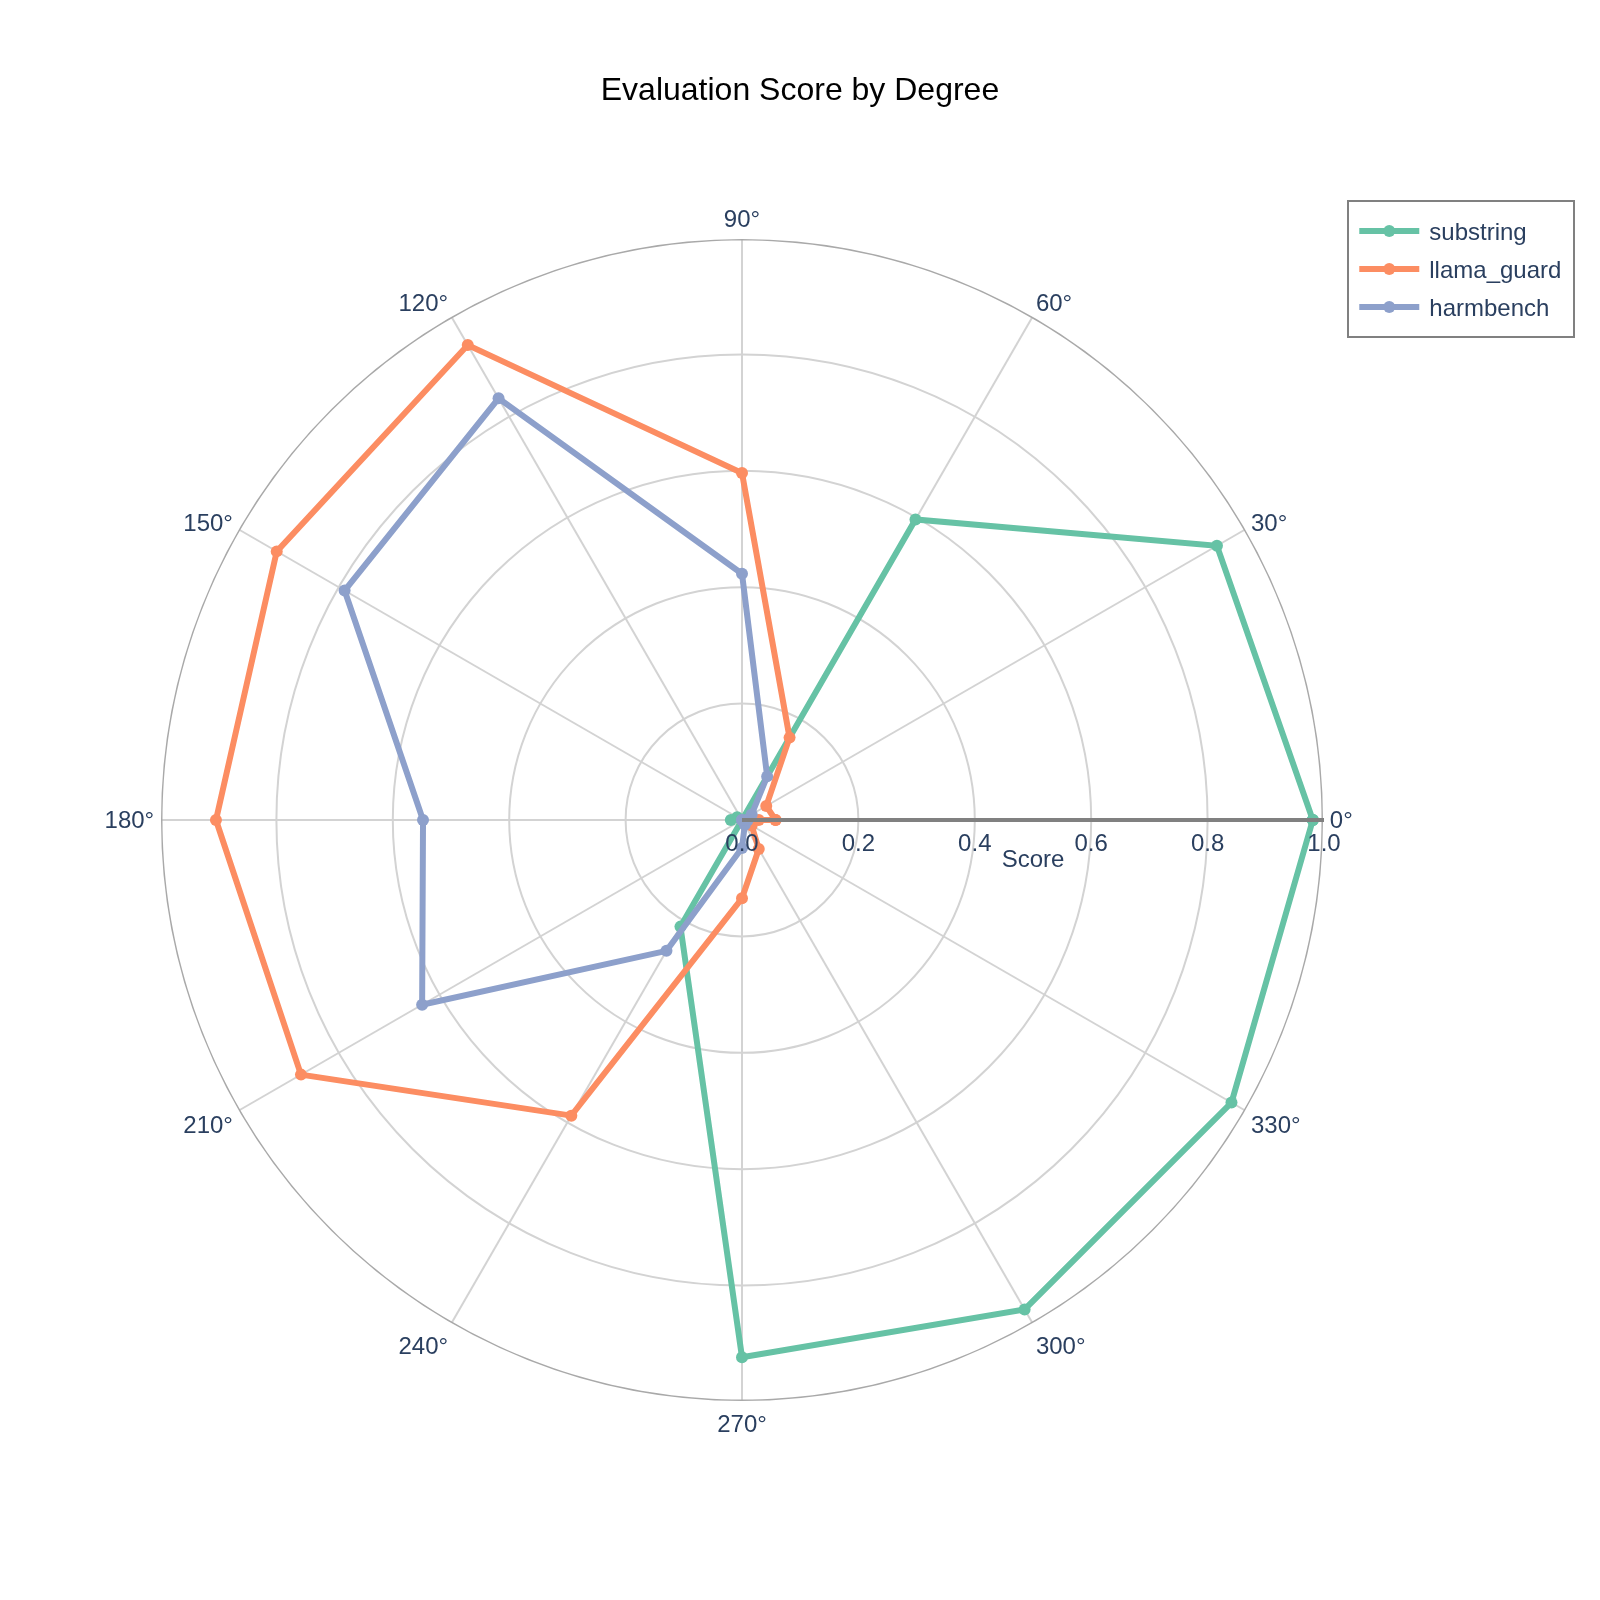

📊 Static image displayed for GitLab compatibility


In [7]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import numpy as np
from typing import Dict, List, Tuple
import plotly.colors as pc

def plot_spider_chart_plotly(
    data_dict: Dict[str, List[Tuple[float, float]]],
    width: int = 800,
    height: int = 800,
    title: str = None,
    save_static: bool = True,
    static_filename: str = "spider_chart.png"
):
    """
    Plot an interactive spider/radar chart with GitLab compatibility.
    
    Args:
        data_dict: Dictionary mapping metric names to lists of (degree, score) tuples
                  Scores should be in the range [0, 1]
        width: Figure width in pixels
        height: Figure height in pixels
        title: Custom title for the chart
        save_static: Whether to save static PNG for GitLab viewing
        static_filename: Filename for static image
    """
    # Extract unique degrees from all data series and sort them
    all_degrees = set()
    for points in data_dict.values():
        for degree, _ in points:
            all_degrees.add(degree)
    
    degrees = np.array(sorted(all_degrees))
    
    # Create figure
    fig = go.Figure()
    
    # Generate automatic colors using Plotly's color palette
    n_series = len(data_dict)
    colors = px.colors.qualitative.Set2[:n_series] if n_series <= len(px.colors.qualitative.Set2) else px.colors.qualitative.Plotly
    
    # Add outer boundary circle at radius 1.0 FIRST (so it appears as background)
    theta_circle = np.linspace(0, 360, 361)  # Full circle with 1-degree steps
    fig.add_trace(go.Scatterpolar(
        r=np.full_like(theta_circle, 1.0),
        theta=theta_circle,
        mode='lines',
        name='Max score (1.0)',
        line=dict(color='darkgray', width=2.5),
        showlegend=False,
        hoverinfo='skip'  # Don't show hover for the boundary circle
    ))
    
    for idx, (metric_name, points) in enumerate(data_dict.items()):
        # Create a dictionary for quick lookup
        point_dict = {degree: score for degree, score in points}
        
        # Extract scores in order of degrees
        scores = []
        theta_values = []
        for deg in degrees:
            if deg in point_dict:
                scores.append(point_dict[deg])
                theta_values.append(deg)
        
        scores = np.array(scores)
        theta_values = np.array(theta_values)
        
        # Sort data by theta for proper line connection
        sort_indices = np.argsort(theta_values)
        theta_sorted = theta_values[sort_indices]
        scores_sorted = scores[sort_indices]
        
        # Close the circle by appending the first point at the end
        theta_closed = np.append(theta_sorted, theta_sorted[0])
        scores_closed = np.append(scores_sorted, scores_sorted[0])
        
        # Add the main line trace (without fill)
        fig.add_trace(go.Scatterpolar(
            r=scores_closed,
            theta=theta_closed,
            mode='lines+markers',
            name=metric_name,
            line=dict(color=colors[idx % len(colors)], width=3),
            marker=dict(size=6, color=colors[idx % len(colors)]),
            hovertemplate=f'<b>{metric_name}</b><br>' +
                         'Degree: %{theta}°<br>' +
                         'Score: %{r:.3f}<br>' +
                         '<extra></extra>'
        ))
    
    # Create radial tick values from 0 to 1
    radial_ticks = np.linspace(0, 1, 6)  # 0, 0.2, 0.4, 0.6, 0.8, 1.0
    
    # Prepare degree labels (prioritize 0 over 360 if both exist)
    display_degrees = degrees.copy()
    if 0 in degrees and 360 in degrees:
        display_degrees = degrees[degrees != 360]  # Remove 360, keep 0
    
    # Update layout
    if title is None:
        title = 'Evaluation Score by Degree'
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1],
                tickvals=radial_ticks,
                ticktext=[f'{tick:.1f}' for tick in radial_ticks],
                title=dict(text='Score', font=dict(size=12)),
                gridcolor='lightgray',
                gridwidth=1,
                showline=True,
                linecolor='gray',
                linewidth=2,
            ),
            angularaxis=dict(
                tickvals=display_degrees,
                ticktext=[f'{int(d)}°' for d in display_degrees],
                direction='counterclockwise',
                rotation=0,  # Start from top
                gridcolor='lightgray',
                gridwidth=1,
            ),
            bgcolor='white'
        ),
        title=dict(
            text=title,
            x=0.5,
            font=dict(size=16, color='black'),
            pad=dict(t=20)
        ),
        showlegend=True,
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='gray',
            borderwidth=1
        ),
        width=width,
        height=height,
        paper_bgcolor='white',
        plot_bgcolor='white'
    )
    
    # GitLab Compatibility: Save static image
    if save_static:
        try:
            fig.write_image(static_filename, width=width, height=height, scale=2)
            print(f"✅ Static image saved as {static_filename}")
            
            # Display static image in Jupyter
            try:
                from IPython.display import Image, display
                display(Image(static_filename))
                print("📊 Static image displayed for GitLab compatibility")
            except ImportError:
                print("ℹ️ IPython not available, static image saved but not displayed")
                
        except Exception as e:
            print(f"⚠️ Could not save static image: {e}")
            print("💡 Install kaleido: pip install kaleido")
    
    return fig



# Create the plot
fig = plot_spider_chart_plotly(
    data_dict,
    width=800,
    height=800,
    save_static=True,
    static_filename="qwen2.5-3b-instruct.png"
)

# Show the plot
# fig.show()

# Optionally save as HTML
# fig.write_html("qwen2.5-3b-instruct.html")

##################################################
# Display the static image in notebook
# from IPython.display import Image, display
# display(Image("qwen2.5-3b-instruct.png"))

✅ Static image saved as llama-3.2-3b-instruct.png


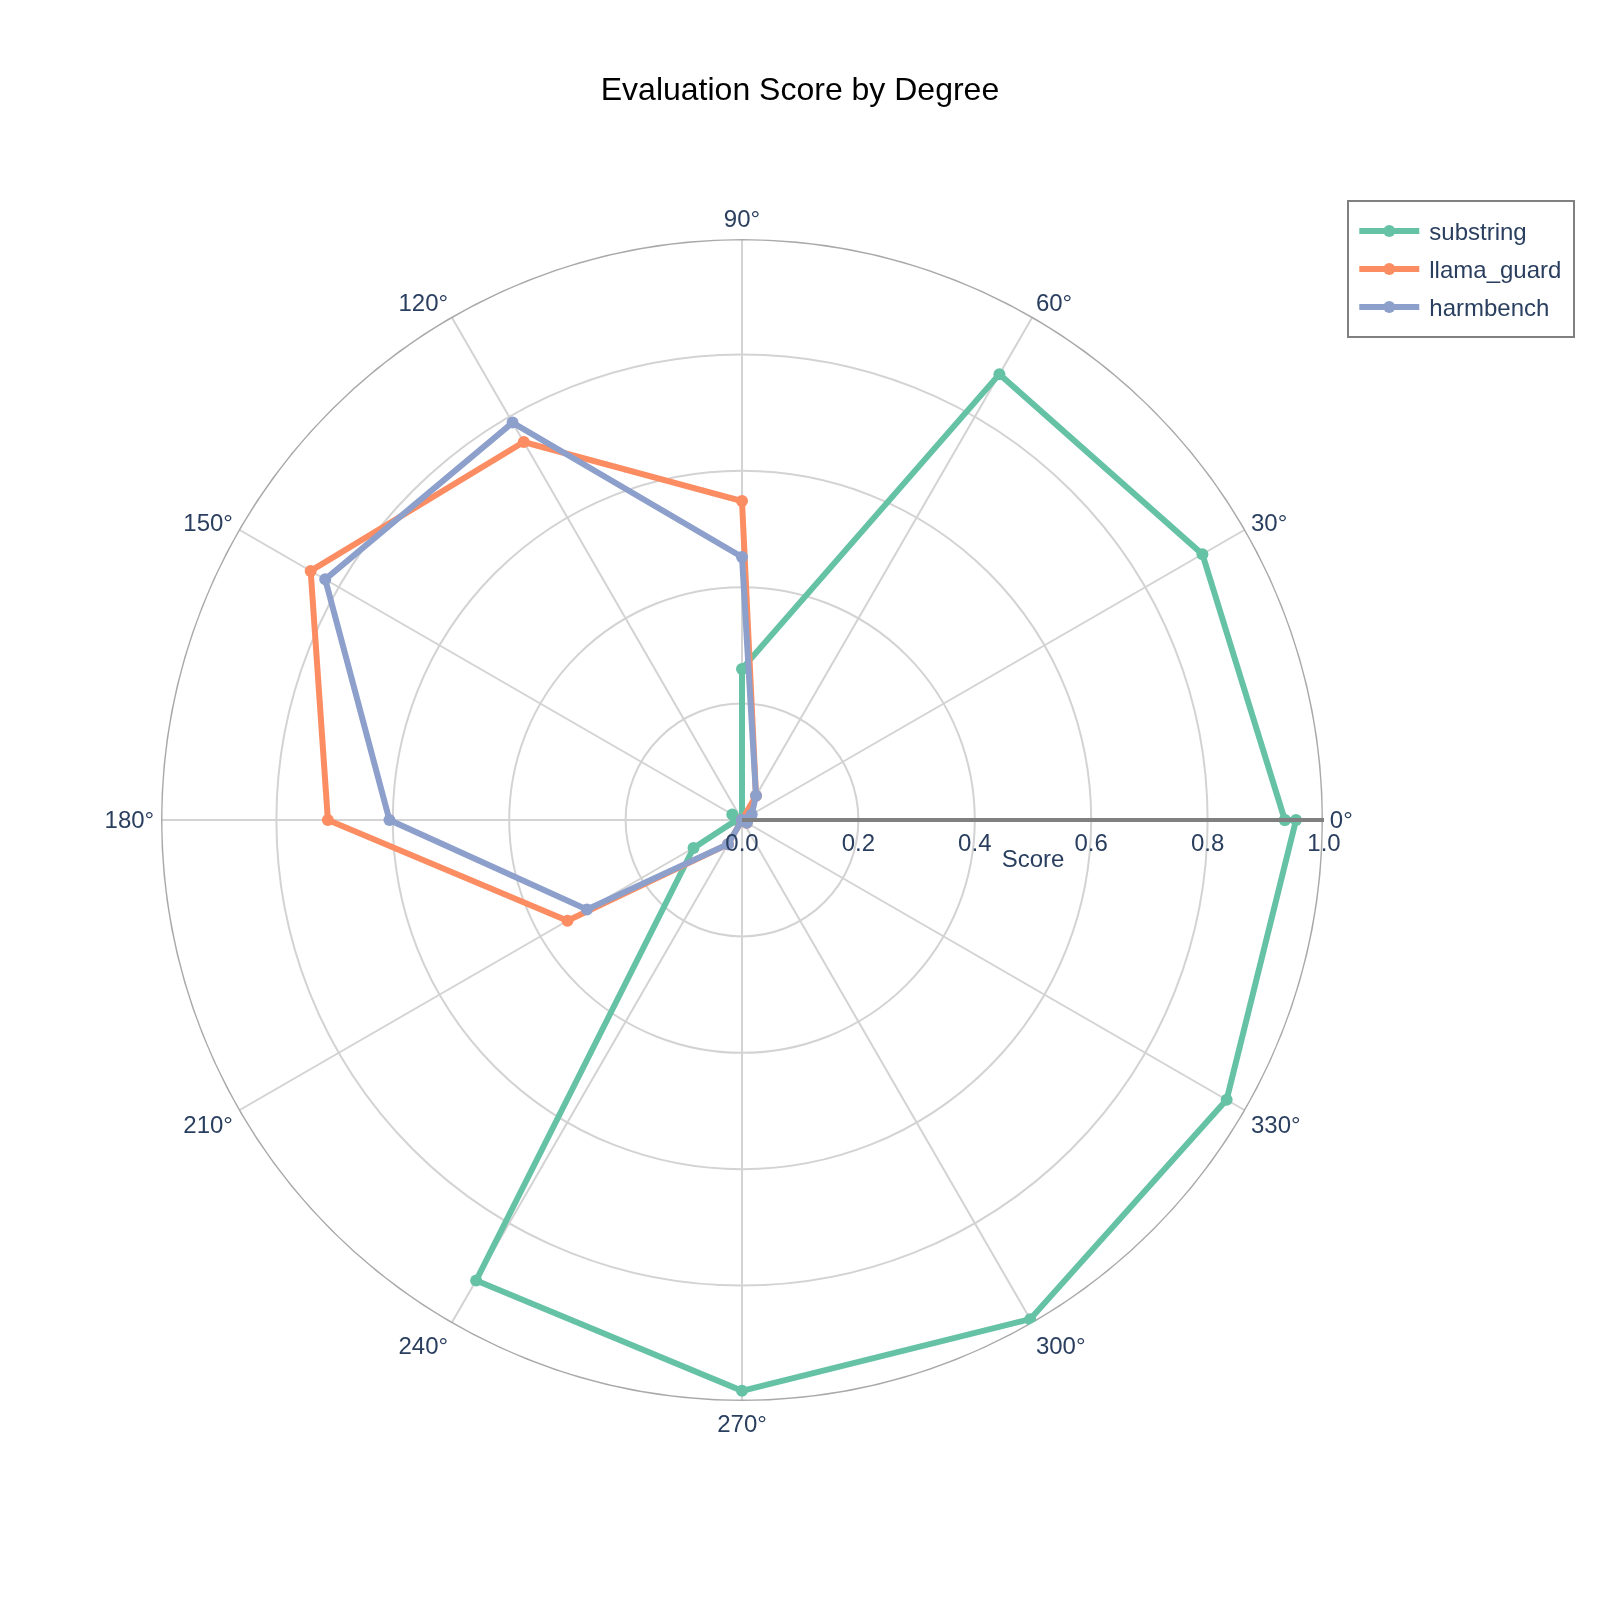

📊 Static image displayed for GitLab compatibility


In [8]:
# Create the plot
fig = plot_spider_chart_plotly(
    meta_llama_3_2_3b_dict,
    width=800,
    height=800,
    save_static=True,
    static_filename="llama-3.2-3b-instruct.png"
)

# Show the plot
# fig.show()

# Optionally save as HTML
# fig.write_html("llama-3.2-3b-instruct.html")


# Display the static image in notebook
# from IPython.display import Image, display
# display(Image("llama-3.2-3b-instruct.png"))